# EIT Reconstruction Demo — Gap Electrode Model

This notebook demonstrates the complete difference-EIT pipeline.
All hyperparameters are configurable in **Cell 2**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "..") if "examples" in os.getcwd() else ".")

from eitkit.mesh import make_circle_mesh, place_electrodes
from eitkit.protocol import adjacent_pattern, measurement_pairs, add_noise
from eitkit.forward import simulate, compute_jacobian
from eitkit.utils import make_phantom, plot_mesh, plot_conductivity, plot_voltages
from eitkit.inverse import tikhonov_solve, choose_lambda, tv_solve, build_gradient_op

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150})
print("eitkit ready.")


eitkit ready.


## Cell 2 — Hyperparameters

Tune these values to change the experiment setup.


In [2]:
# ===== Experiment Hyperparameters =====
N_ELECTRODES = 16          # number of electrodes (>= 4)
H0 = 0.08                  # mesh edge length (smaller = finer)
SNR_DB = 45.0              # signal-to-noise ratio
CURRENT = 1.0              # injected current (A)
SEED = 42                  # RNG seed

# --- Phantom selection ---
# Pick one: single_circle, two_circles, circle_ellipse, ring, custom
PHANTOM_PRESET = "circle_ellipse"
SIGMA_BG = 1.0             # background conductivity (S/m)

# --- Tikhonov ---
LAMBDA_TIK = 1e-7          # regularisation parameter

# --- TV ---
ALPHA_TV = 5e-8            # regularisation strength
RHO_TV = "auto"            # ADMM penalty ("auto" for trace scaling)
TV_MAX_ITER = 300

print(f"L={N_ELECTRODES}, h0={H0}, SNR={SNR_DB} dB, phantom={PHANTOM_PRESET}")
print(f"Tikhonov lambda={LAMBDA_TIK:.0e}, TV alpha={ALPHA_TV:.0e}")


L=16, h0=0.08, SNR=45.0 dB, phantom=circle_ellipse
Tikhonov lambda=1e-07, TV alpha=5e-08


## Cell 3 — Mesh Generation

Generate a quality triangular mesh on the unit disc using DistMesh2D
(Persson & Strang, 2004) and place $L$ electrodes uniformly on the boundary.


Mesh: 574 nodes, 1116 elements, 22 boundary nodes, h_mean=0.0744


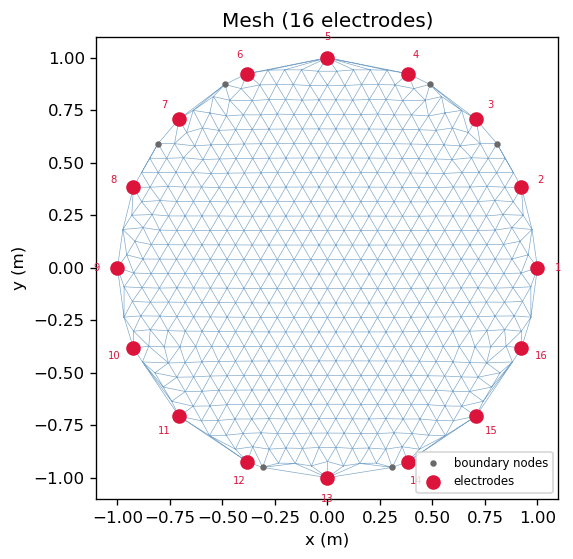

In [3]:
mesh = make_circle_mesh(n_electrodes=N_ELECTRODES, h0=H0, seed=SEED)
ec = place_electrodes(mesh, n_electrodes=N_ELECTRODES)
print(f"Mesh: {mesh.n_nodes} nodes, {mesh.n_elements} elements, "
      f"{mesh.n_boundary_nodes} boundary nodes, h_mean={mesh.h_mean:.4f}")

fig, ax = plot_mesh(mesh, elec_config=ec,
                    title=f"Mesh ({N_ELECTRODES} electrodes)")
plt.show()


## Cell 4 — Conductivity Phantom

Build a piecewise-constant conductivity distribution. The predefined
presets use moderate contrasts that stay within the linear (Born) regime.


True delta_sigma range: [-0.50, +0.60] S/m


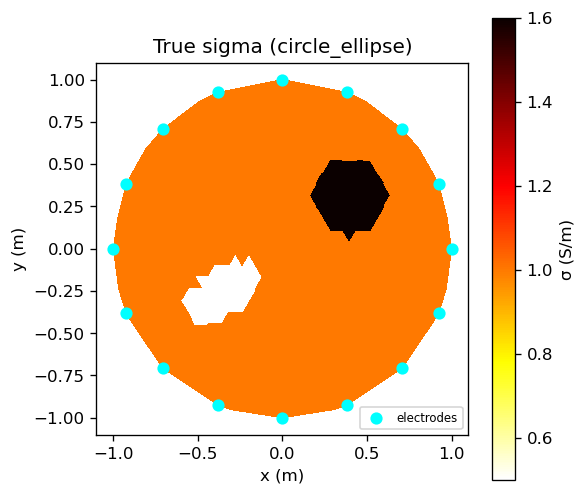

In [4]:
sigma_ref = np.full(mesh.n_elements, SIGMA_BG)

presets = {
    "single_circle": [
        {"shape": "circle", "cx": 0.0, "cy": 0.0, "r": 0.30, "sigma": 1.6},
    ],
    "two_circles": [
        {"shape": "circle", "cx":  0.40, "cy":  0.30, "r": 0.22, "sigma": 1.6},
        {"shape": "circle", "cx": -0.35, "cy": -0.25, "r": 0.18, "sigma": 0.5},
    ],
    "circle_ellipse": [
        {"shape": "circle",  "cx":  0.40, "cy":  0.30, "r": 0.22, "sigma": 1.6},
        {"shape": "ellipse", "cx": -0.35, "cy": -0.25, "a": 0.25, "b": 0.14,
         "theta": 0.6, "sigma": 0.5},
    ],
    "ring": [
        {"shape": "ring", "cx": 0.0, "cy": 0.0,
         "r_inner": 0.25, "r_outer": 0.50, "sigma": 1.6},
    ],
    "custom": [],  # edit below
}

if PHANTOM_PRESET == "custom":
    inclusions = [
        {"shape": "circle", "cx": 0.0, "cy": 0.3, "r": 0.15, "sigma": 1.5},
    ]
else:
    inclusions = presets[PHANTOM_PRESET]

sigma_true = make_phantom(mesh, inclusions, sigma_background=SIGMA_BG)
delta_sigma_true = sigma_true - sigma_ref
rng = delta_sigma_true.min(), delta_sigma_true.max()
print(f"True delta_sigma range: [{rng[0]:+.2f}, {rng[1]:+.2f}] S/m")

fig, ax = plot_conductivity(mesh, sigma_true, cmap="hot_r",
                            title=f"True sigma ({PHANTOM_PRESET})",
                            elec_config=ec)
plt.show()


## Cell 5 — Forward Simulation

Solve the FEM system for each adjacent-drive pattern and extract
$P = L(L-3)$ difference voltages $\delta V = V(\sigma) - V(\sigma_0)$.


Drive steps: 16, measurement pairs: 208
norm(dV_clean) = 3.3431e-02
norm(dV_noisy) = 3.3440e-02


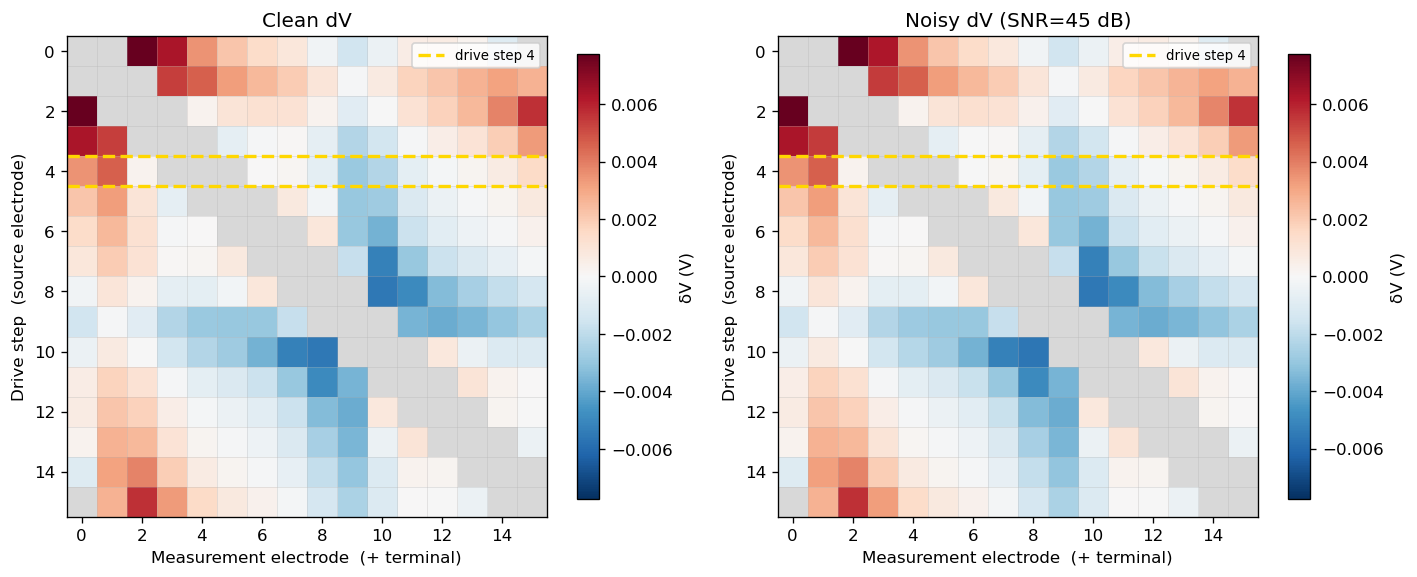

In [5]:
drive = adjacent_pattern(N_ELECTRODES)
meas  = measurement_pairs(N_ELECTRODES)
P = len(meas)
print(f"Drive steps: {len(drive)}, measurement pairs: {P}")

dV_clean = simulate(mesh, ec, sigma_true, drive, meas,
                    current=CURRENT, sigma0=SIGMA_BG)
dV_noisy = add_noise(dV_clean, snr_db=SNR_DB, rng=SEED)
print(f"norm(dV_clean) = {np.linalg.norm(dV_clean):.4e}")
print(f"norm(dV_noisy) = {np.linalg.norm(dV_noisy):.4e}")

# Voltage matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_voltages(meas, dV_clean, n_electrodes=N_ELECTRODES, ax=ax1,
              title="Clean dV", highlight_drive=4)
plot_voltages(meas, dV_noisy, n_electrodes=N_ELECTRODES, ax=ax2,
              title=f"Noisy dV (SNR={SNR_DB:.0f} dB)", highlight_drive=4)
fig.tight_layout()
plt.show()


## Cell 6 — Jacobian (Sensitivity Matrix)

Compute $J_{ie} = \partial V_i / \partial \sigma_e$ via the adjoint method.
Requires $L$ forward + $Q \leq L$ adjoint solves.


In [6]:
J = compute_jacobian(mesh, ec, sigma_ref, drive, meas, current=CURRENT)
print(f"Jacobian shape: {J.shape}  (P={J.shape[0]}, E={J.shape[1]})")

# Verify linear approximation
dV_linear = J @ delta_sigma_true
lin_err = np.linalg.norm(dV_clean - dV_linear) / np.linalg.norm(dV_clean)
print(f"Linearisation error = {lin_err:.4f}")
if lin_err > 0.5:
    print("  WARNING: Born approximation is poor.")
else:
    print("  Linear approximation is acceptable.")


Jacobian shape: (208, 1116)  (P=208, E=1116)
Linearisation error = 0.2680
  Linear approximation is acceptable.


## Cell 7 — Tikhonov Reconstruction

Solve $(J^T J + \lambda I)\,\delta\hat\sigma = J^T \delta V$.
The L-curve is shown for automatic $\lambda$ selection.


L-curve optimal lambda = 5.68e-05
Using fixed lambda = 1e-07
Tikhonov norm(ds) = 4.376
Tikhonov range = [-0.546, +0.476] S/m
Tikhonov residual = 5.2095e-04


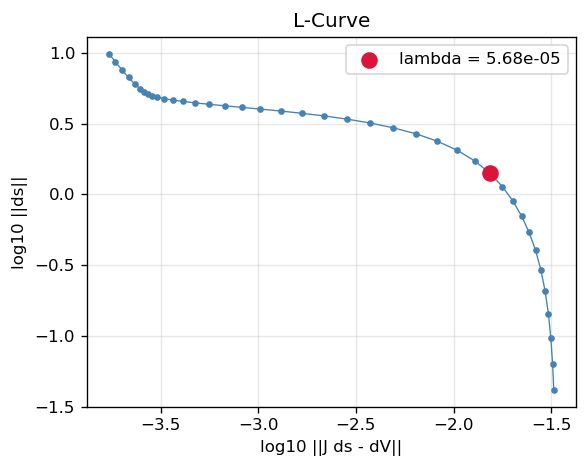

In [7]:
# L-curve for reference
lam_opt, residuals, sol_norms = choose_lambda(J, dV_noisy, n_points=40)
print(f"L-curve optimal lambda = {lam_opt:.2e}")
print(f"Using fixed lambda = {LAMBDA_TIK:.0e}")

ds_tik = tikhonov_solve(J, dV_noisy, lambda_=LAMBDA_TIK)
sigma_tik = sigma_ref + ds_tik
print(f"Tikhonov norm(ds) = {np.linalg.norm(ds_tik):.3f}")
print(f"Tikhonov range = [{ds_tik.min():+.3f}, {ds_tik.max():+.3f}] S/m")
print(f"Tikhonov residual = {np.linalg.norm(J @ ds_tik - dV_noisy):.4e}")

# L-curve plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(residuals, sol_norms, "o-", markersize=3, linewidth=0.8, color="steelblue")
idx = np.argmax(np.abs(np.diff(np.diff(residuals)))) + 1
ax.scatter(residuals[idx], sol_norms[idx], s=80, color="crimson", zorder=5,
           label=f"lambda = {lam_opt:.2e}")
ax.set_xlabel("log10 ||J ds - dV||")
ax.set_ylabel("log10 ||ds||")
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title("L-Curve")
fig.tight_layout(); plt.show()


## Cell 8 — Total Variation Reconstruction (ADMM)

Minimise $\frac{1}{2}\|J\,\delta\sigma - \delta V\|^2 + \alpha\|D\,\delta\sigma\|_1$
via the Alternating Direction Method of Multipliers (Boyd et al., 2011).
The penalty $\rho$ is auto-scaled to balance $J^T J$ and $D^T D$.


In [8]:
D = build_gradient_op(mesh)
ds_tv = tv_solve(J, dV_noisy, alpha=ALPHA_TV, mesh=mesh, rho=RHO_TV,
                 max_iter=TV_MAX_ITER, tol=1e-4)
sigma_tv = sigma_ref + ds_tv
print(f"TV norm(ds) = {np.linalg.norm(ds_tv):.3f}")
print(f"TV range = [{ds_tv.min():+.3f}, {ds_tv.max():+.3f}] S/m")
print(f"TV gradient norm = {np.linalg.norm(D @ ds_tv, 1):.3f}")
print(f"TV residual = {np.linalg.norm(J @ ds_tv - dV_noisy):.4e}")


TV norm(ds) = 4.813
TV range = [-0.539, +0.428] S/m
TV gradient norm = 19.583
TV residual = 5.5398e-04


## Cell 9 — Reconstruction Comparison

Side-by-side: True | Tikhonov | TV.


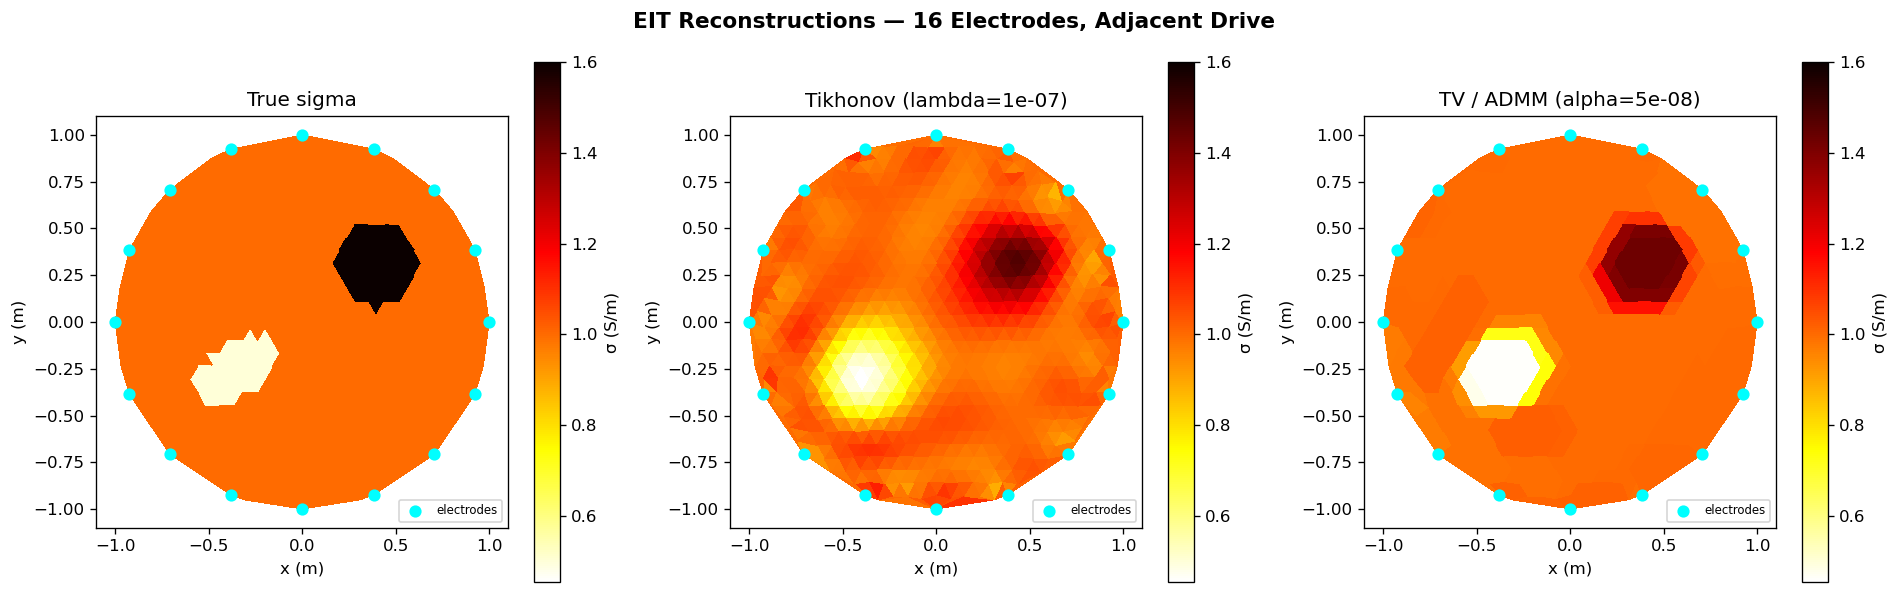

In [9]:
vmin = min(sigma_true.min(), sigma_tik.min(), sigma_tv.min())
vmax = max(sigma_true.max(), sigma_tik.max(), sigma_tv.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"EIT Reconstructions — {N_ELECTRODES} Electrodes, Adjacent Drive",
             fontsize=13, fontweight="bold")

plot_conductivity(mesh, sigma_true, ax=axes[0],
                  title="True sigma", cmap="hot_r",
                  vmin=vmin, vmax=vmax, elec_config=ec)
plot_conductivity(mesh, sigma_tik, ax=axes[1],
                  title=f"Tikhonov (lambda={LAMBDA_TIK:.0e})", cmap="hot_r",
                  vmin=vmin, vmax=vmax, elec_config=ec)
plot_conductivity(mesh, sigma_tv, ax=axes[2],
                  title=f"TV / ADMM (alpha={ALPHA_TV:.0e})", cmap="hot_r",
                  vmin=vmin, vmax=vmax, elec_config=ec)
fig.tight_layout(); plt.show()


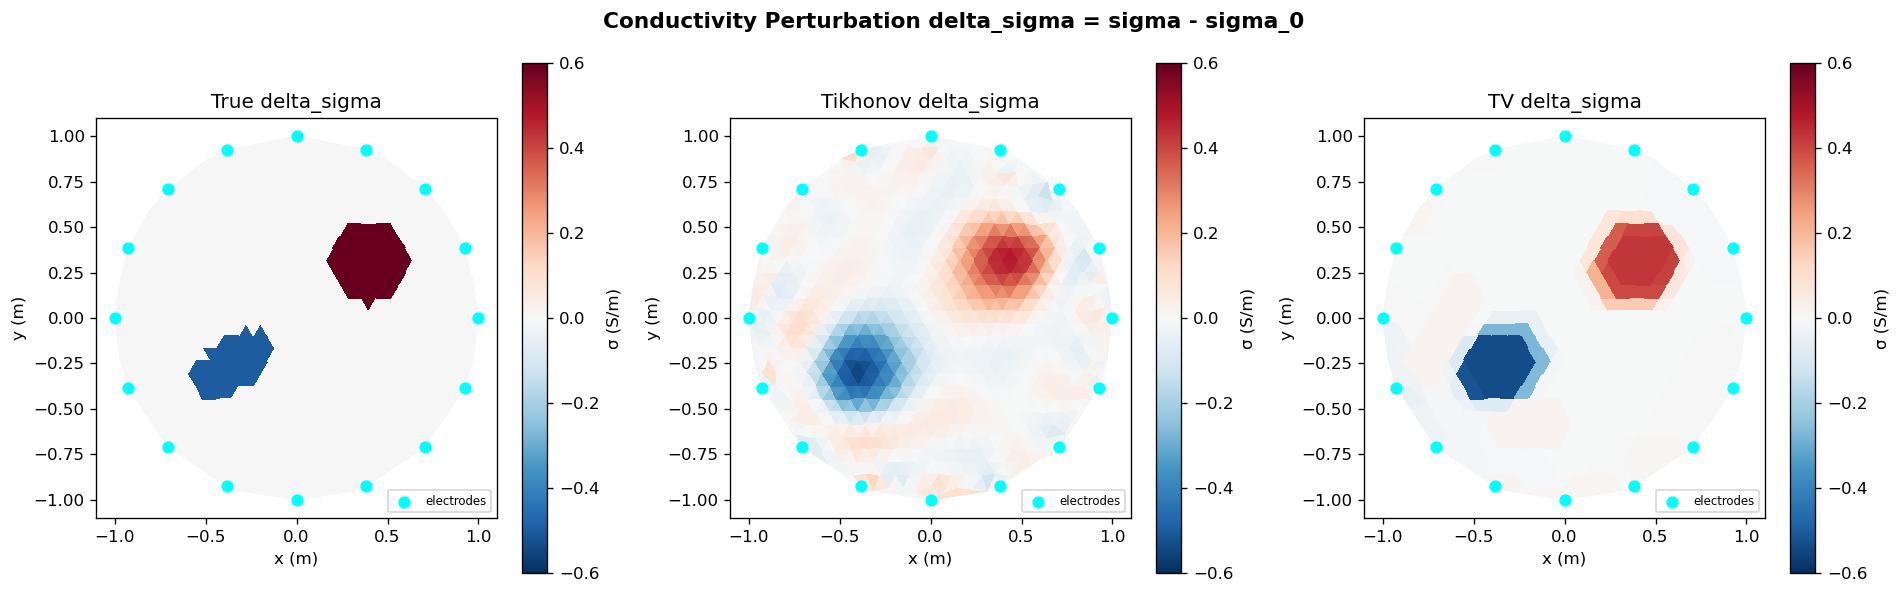

In [10]:
# Conductivity perturbation delta_sigma = sigma - sigma_bg
pert_vmax = max(np.abs(delta_sigma_true).max(),
                np.abs(ds_tik).max(), np.abs(ds_tv).max())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Conductivity Perturbation delta_sigma = sigma - sigma_0",
             fontsize=13, fontweight="bold")

plot_conductivity(mesh, delta_sigma_true, ax=axes[0],
                  title="True delta_sigma", cmap="RdBu_r",
                  vmin=-pert_vmax, vmax=pert_vmax, elec_config=ec)
plot_conductivity(mesh, ds_tik, ax=axes[1],
                  title="Tikhonov delta_sigma", cmap="RdBu_r",
                  vmin=-pert_vmax, vmax=pert_vmax, elec_config=ec)
plot_conductivity(mesh, ds_tv, ax=axes[2],
                  title="TV delta_sigma", cmap="RdBu_r",
                  vmin=-pert_vmax, vmax=pert_vmax, elec_config=ec)
fig.tight_layout(); plt.show()


## Cell 10 — Error Metrics


In [11]:
rel_tik = np.linalg.norm(delta_sigma_true - ds_tik) / np.linalg.norm(delta_sigma_true)
rel_tv  = np.linalg.norm(delta_sigma_true - ds_tv)  / np.linalg.norm(delta_sigma_true)
res_tik = np.linalg.norm(J @ ds_tik - dV_noisy) / np.linalg.norm(dV_noisy)
res_tv  = np.linalg.norm(J @ ds_tv  - dV_noisy) / np.linalg.norm(dV_noisy)

print("=" * 55)
print(f"  Config: L={N_ELECTRODES}, h0={H0}, SNR={SNR_DB} dB, phantom={PHANTOM_PRESET}")
print(f"  Mesh: {mesh.n_nodes} nodes, {mesh.n_elements} elements, P={P}")
print(f"  Linearisation error: {lin_err:.4f}")
print("-" * 55)
print(f"  Tikhonov (lambda={LAMBDA_TIK:.0e}):")
print(f"    rel. error = {rel_tik:.4f},  rel. residual = {res_tik:.4f}")
print(f"  TV (alpha={ALPHA_TV:.0e}):")
print(f"    rel. error = {rel_tv:.4f},  rel. residual = {res_tv:.4f}")
print("=" * 55)


  Config: L=16, h0=0.08, SNR=45.0 dB, phantom=circle_ellipse
  Mesh: 574 nodes, 1116 elements, P=208
  Linearisation error: 0.2680
-------------------------------------------------------
  Tikhonov (lambda=1e-07):
    rel. error = 0.5772,  rel. residual = 0.0156
  TV (alpha=5e-08):
    rel. error = 0.4252,  rel. residual = 0.0166
